# NSE Equity Futures — Depth Order Book Exploration

Run from project root: `/Users/krishhiv/Desktop/argus-alpha-research/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

# Derive project root from notebook location (research/notebooks/ → 2 levels up)
PROJECT_ROOT = Path("__file__").resolve().parent.parent.parent
# Fallback: hardcoded absolute path if the above doesn't resolve correctly in Jupyter
PROJECT_ROOT = Path("/Users/krishhiv/Desktop/argus-alpha-research")

FILE = (
    PROJECT_ROOT
    / "data/raw/depth"
    / "trading_date=2026-05-06"
    / "symbol=HDFCBANK-May2026-FUT"
    / "compacted-depth-2026-05-06-HDFCBANK-May2026-FUT-1778062240874443114.parquet"
)

print(f"Loading: {FILE}")
print(f"Exists : {FILE.exists()}")

Loading: /Users/krishhiv/Desktop/argus-alpha-research/data/raw/depth/trading_date=2026-05-06/symbol=HDFCBANK-May2026-FUT/compacted-depth-2026-05-06-HDFCBANK-May2026-FUT-1778062240874443114.parquet
Exists : True


## Section 1 — Load & Schema

In [2]:
df = pd.read_parquet(FILE)
print(f"Shape: {df.shape}")
print(f"\nDtype summary:")
print(df.dtypes.value_counts())
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (94476, 135)

Dtype summary:
int64                  82
float64                40
object                 10
int32                   2
datetime64[ns, UTC]     1
Name: count, dtype: int64

First 3 rows:


,collector_received_at,trading_date,contract_key,security_id,exchange,segment,feed_exchange_segment,underlying_symbol,symbol_name,display_name,...,bid_orders_19,ask_price_19,ask_qty_19,ask_orders_19,bid_price_20,bid_qty_20,bid_orders_20,ask_price_20,ask_qty_20,ask_orders_20
0,2026-05-06 03:45:00.406350+00:00,2026-05-06,HDFCBANK_CURRENT_FUT,66180,NSE,D,NSE_FNO,HDFCBANK,HDFCBANK-May2026-FUT,HDFCBANK MAY FUT,...,1,783.95,3850,2,775.45,2200,4,784.00,3300,6
1,2026-05-06 03:45:00.808917+00:00,2026-05-06,HDFCBANK_CURRENT_FUT,66180,NSE,D,NSE_FNO,HDFCBANK,HDFCBANK-May2026-FUT,HDFCBANK MAY FUT,...,1,783.45,550,1,777.20,1100,1,783.80,2750,2
2,2026-05-06 03:45:01.008078+00:00,2026-05-06,HDFCBANK_CURRENT_FUT,66180,NSE,D,NSE_FNO,HDFCBANK,HDFCBANK-May2026-FUT,HDFCBANK MAY FUT,...,1,783.40,3300,3,777.50,1100,1,783.45,550,1


In [3]:
# Column list grouped by category
levels = [f"{i:02d}" for i in range(1, 21)]

bid_price_cols   = [f"bid_price_{l}"  for l in levels]
bid_qty_cols     = [f"bid_qty_{l}"    for l in levels]
bid_orders_cols  = [f"bid_orders_{l}" for l in levels]
ask_price_cols   = [f"ask_price_{l}"  for l in levels]
ask_qty_cols     = [f"ask_qty_{l}"    for l in levels]
ask_orders_cols  = [f"ask_orders_{l}" for l in levels]

price_qty_order_cols = (
    bid_price_cols + bid_qty_cols + bid_orders_cols +
    ask_price_cols + ask_qty_cols + ask_orders_cols
)
meta_cols = [c for c in df.columns if c not in price_qty_order_cols]

print("--- Metadata columns ---")
print(meta_cols)
print("\n--- Bid price cols (01-20) ---")
print(bid_price_cols)
print("\n--- Bid qty cols (01-20) ---")
print(bid_qty_cols)
print("\n--- Bid orders cols (01-20) ---")
print(bid_orders_cols)
print("\n--- Ask price cols (01-20) ---")
print(ask_price_cols)
print("\n--- Ask qty cols (01-20) ---")
print(ask_qty_cols)
print("\n--- Ask orders cols (01-20) ---")
print(ask_orders_cols)

--- Metadata columns ---
['collector_received_at', 'trading_date', 'contract_key', 'security_id', 'exchange', 'segment', 'feed_exchange_segment', 'underlying_symbol', 'symbol_name', 'display_name', 'expiry_date', 'expiry_flag', 'message_sequence', 'bid_response_code', 'ask_response_code']

--- Bid price cols (01-20) ---
['bid_price_01', 'bid_price_02', 'bid_price_03', 'bid_price_04', 'bid_price_05', 'bid_price_06', 'bid_price_07', 'bid_price_08', 'bid_price_09', 'bid_price_10', 'bid_price_11', 'bid_price_12', 'bid_price_13', 'bid_price_14', 'bid_price_15', 'bid_price_16', 'bid_price_17', 'bid_price_18', 'bid_price_19', 'bid_price_20']

--- Bid qty cols (01-20) ---
['bid_qty_01', 'bid_qty_02', 'bid_qty_03', 'bid_qty_04', 'bid_qty_05', 'bid_qty_06', 'bid_qty_07', 'bid_qty_08', 'bid_qty_09', 'bid_qty_10', 'bid_qty_11', 'bid_qty_12', 'bid_qty_13', 'bid_qty_14', 'bid_qty_15', 'bid_qty_16', 'bid_qty_17', 'bid_qty_18', 'bid_qty_19', 'bid_qty_20']

--- Bid orders cols (01-20) ---
['bid_orders_

## Section 2 — Packet Rate & Gaps

In [4]:
# Parse timestamps, sort, compute inter-packet intervals
df["ts"] = pd.to_datetime(df["collector_received_at"], utc=True)
df = df.sort_values("ts").reset_index(drop=True)

intervals_ms = df["ts"].diff().dt.total_seconds().mul(1000)  # milliseconds

duration = df["ts"].iloc[-1] - df["ts"].iloc[0]
print(f"Total rows            : {len(df):,}")
print(f"Session start (UTC)   : {df['ts'].iloc[0]}")
print(f"Session end   (UTC)   : {df['ts'].iloc[-1]}")
print(f"Trading session duration: {duration}")
print()
print("Inter-packet interval (ms):")
print(f"  mean   : {intervals_ms.mean():.2f} ms")
print(f"  median : {intervals_ms.median():.2f} ms")
print(f"  p95    : {intervals_ms.quantile(0.95):.2f} ms")
print(f"  p99    : {intervals_ms.quantile(0.99):.2f} ms")
print(f"  max    : {intervals_ms.max():.2f} ms")

Total rows            : 94,476
Session start (UTC)   : 2026-05-06 03:45:00.406350+00:00
Session end   (UTC)   : 2026-05-06 09:59:59.816459+00:00
Trading session duration: 0 days 06:14:59.410109

Inter-packet interval (ms):
  mean   : 238.15 ms
  median : 200.77 ms
  p95    : 401.19 ms
  p99    : 596.01 ms
  max    : 7408.59 ms


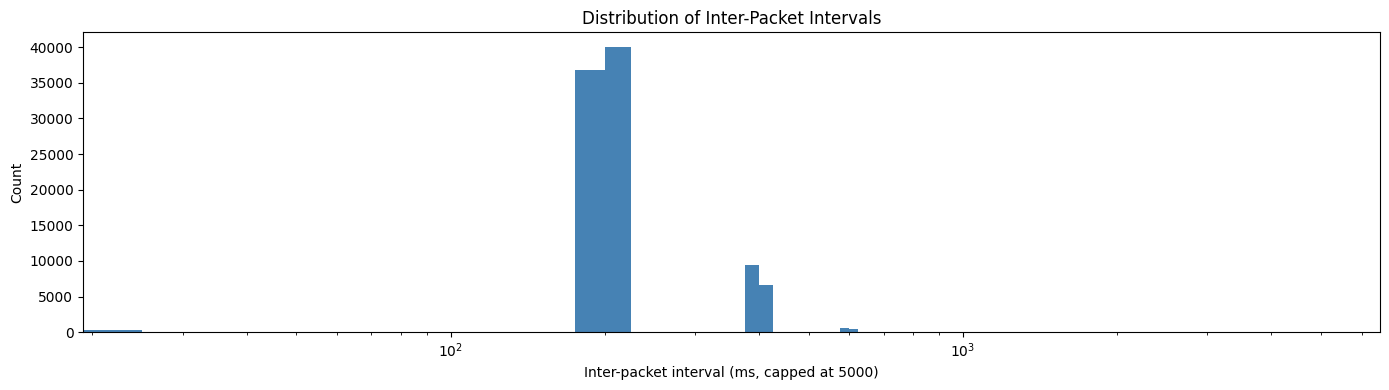

In [5]:
# Histogram of inter-packet intervals (log x-scale, capped at 5000 ms)
fig, ax = plt.subplots(figsize=(14, 4))
data_plot = intervals_ms.dropna().clip(upper=5000)
ax.hist(data_plot, bins=200, color="steelblue", edgecolor="none")
ax.set_xscale("log")
ax.set_xlabel("Inter-packet interval (ms, capped at 5000)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Inter-Packet Intervals")
plt.tight_layout()
plt.show()

In [6]:
# Gaps > 5 seconds
gap_threshold_ms = 5_000
gaps = intervals_ms[intervals_ms > gap_threshold_ms].dropna()
if gaps.empty:
    print("No gaps > 5 seconds found.")
else:
    gap_df = pd.DataFrame({
        "timestamp": df.loc[gaps.index, "ts"].values,
        "gap_ms": gaps.values
    })
    print(f"{len(gap_df)} gap(s) > 5 seconds found:")
    print(gap_df.to_string(index=False))

1 gap(s) > 5 seconds found:
                 timestamp  gap_ms
2026-05-06 05:31:02.613381 7408.59


## Section 3 — Midprice & Spread

In [7]:
TICK = 0.05  # NSE futures tick size

df["midprice"]     = (df["bid_price_01"] + df["ask_price_01"]) / 2
df["spread"]       = df["ask_price_01"] - df["bid_price_01"]
df["spread_ticks"] = df["spread"] / TICK

print(f"Midprice range : {df['midprice'].min():.2f} — {df['midprice'].max():.2f}")
print(f"Mean spread    : {df['spread'].mean():.4f} ({df['spread_ticks'].mean():.2f} ticks)")
pct_one_tick = (df["spread_ticks"].round() == 1).mean() * 100
print(f"% time spread == 1 tick: {pct_one_tick:.1f}%")

Midprice range : 776.60 — 804.53
Mean spread    : 0.2598 (5.20 ticks)
% time spread == 1 tick: 5.9%


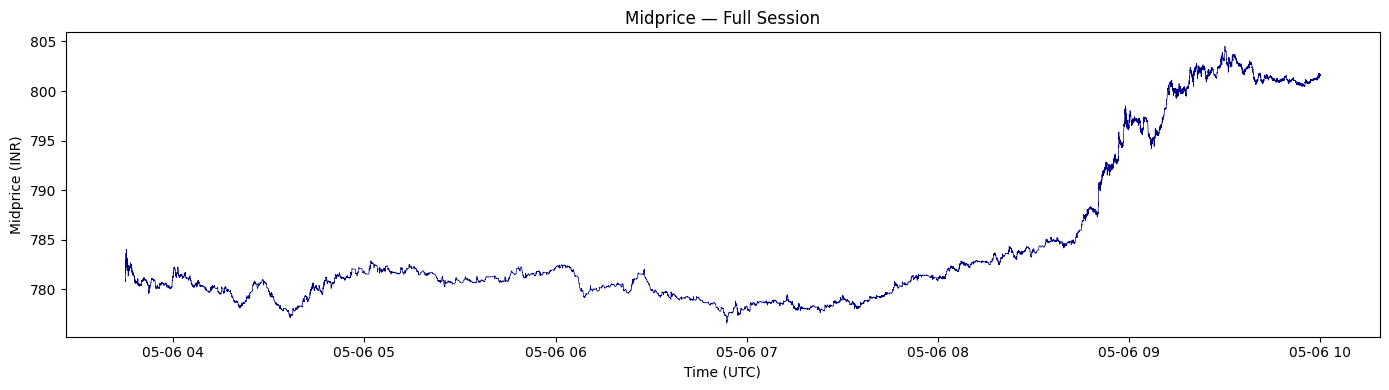

In [8]:
# Midprice time series
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["ts"], df["midprice"], linewidth=0.5, color="navy")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Midprice (INR)")
ax.set_title("Midprice — Full Session")
plt.tight_layout()
plt.show()

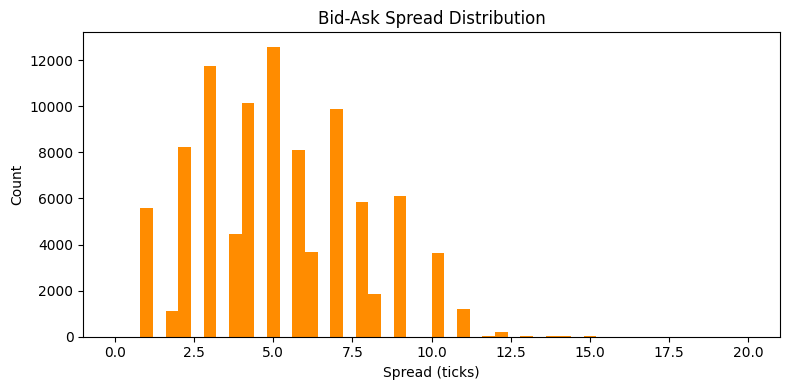

In [9]:
# Spread distribution
fig, ax = plt.subplots(figsize=(8, 4))
valid_spreads = df["spread_ticks"].clip(lower=0, upper=20)
ax.hist(valid_spreads, bins=50, color="darkorange", edgecolor="none")
ax.set_xlabel("Spread (ticks)")
ax.set_ylabel("Count")
ax.set_title("Bid-Ask Spread Distribution")
plt.tight_layout()
plt.show()

Log-normal fit parameters:
  mu    (mean of log spread) : -1.4959
  sigma (std  of log spread) : 0.5917
  Implied median spread      : 0.2240 INR  = 4.48 ticks
  Implied mean spread        : 0.2669 INR  = 5.34 ticks
  Non-positive rows excluded : 1


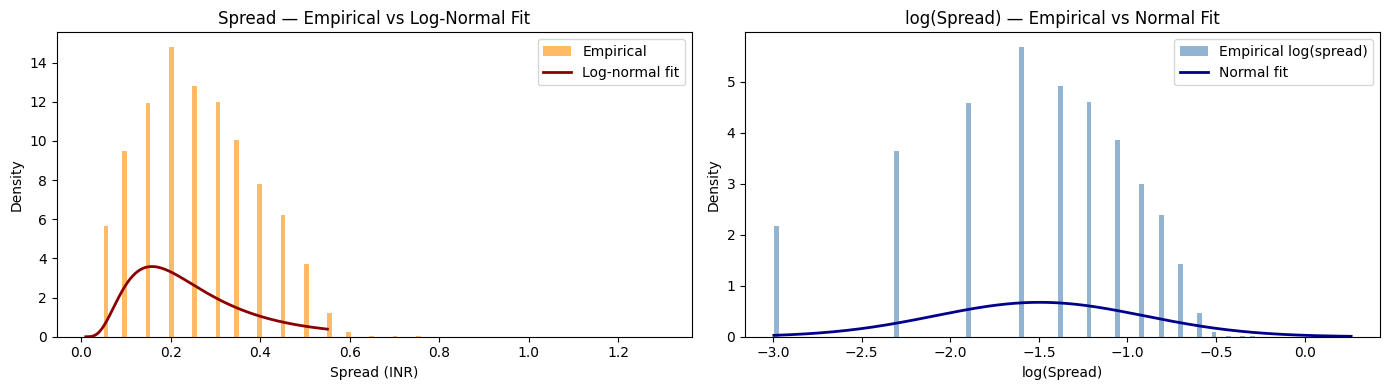

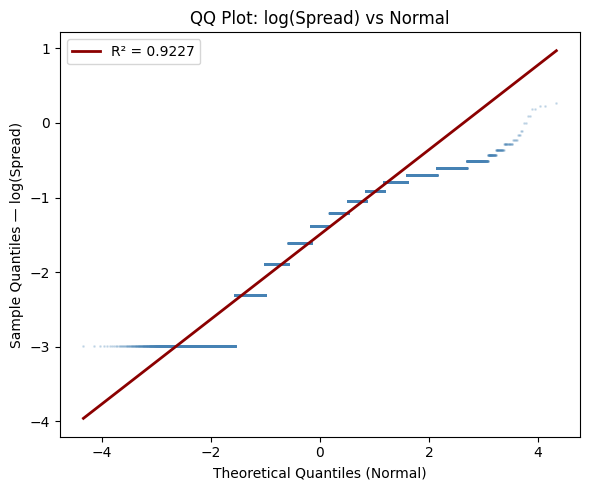

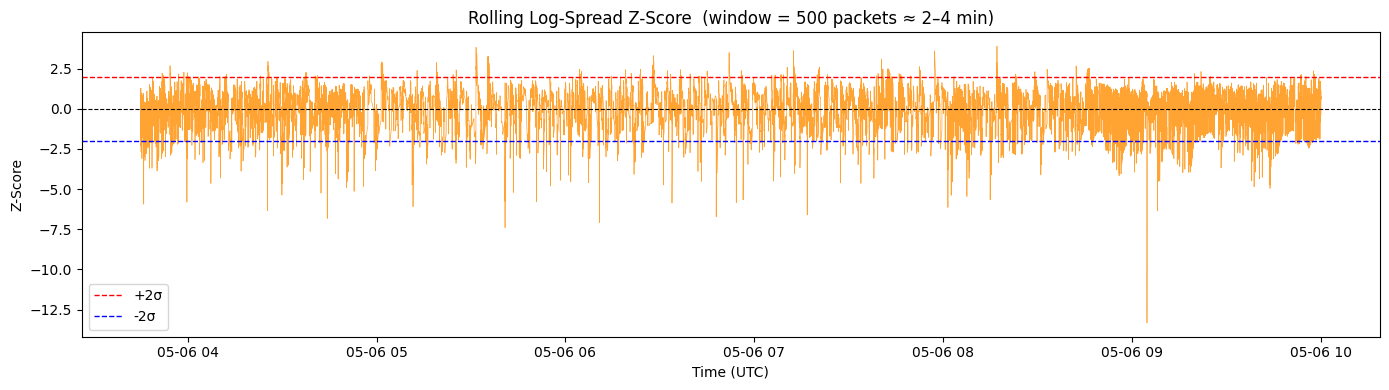


Fraction of session with log_spread_z > +2 (anomalously wide) : 1.2%
Fraction of session with log_spread_z < -2 (anomalously tight): 5.3%


In [25]:
from scipy import stats

# Exclude non-positive spreads before fitting
spread_pos = df["spread"][df["spread"] > 0].values
n_excluded = (df["spread"] <= 0).sum()

# Fit log-normal: log(X) ~ N(mu, sigma). Fix loc=0 (spread is strictly positive).
shape, loc, scale = stats.lognorm.fit(spread_pos, floc=0)
mu_ln    = np.log(scale)   # mean of log(spread)
sigma_ln = shape           # std of log(spread)

print(f"Log-normal fit parameters:")
print(f"  mu    (mean of log spread) : {mu_ln:.4f}")
print(f"  sigma (std  of log spread) : {sigma_ln:.4f}")
print(f"  Implied median spread      : {np.exp(mu_ln):.4f} INR  = {np.exp(mu_ln)/TICK:.2f} ticks")
print(f"  Implied mean spread        : {np.exp(mu_ln + 0.5*sigma_ln**2):.4f} INR  = {np.exp(mu_ln + 0.5*sigma_ln**2)/TICK:.2f} ticks")
print(f"  Non-positive rows excluded : {n_excluded:,}")

# --- Plot 1: empirical histogram vs log-normal PDF (raw and log-transformed) ---
x_range = np.linspace(0.01, np.percentile(spread_pos, 99.5), 500)
lognorm_pdf = stats.lognorm.pdf(x_range, s=sigma_ln, loc=0, scale=np.exp(mu_ln))

log_spread = np.log(spread_pos)
x_log = np.linspace(log_spread.min(), log_spread.max(), 500)
normal_pdf = stats.norm.pdf(x_log, loc=mu_ln, scale=sigma_ln)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(spread_pos, bins=120, density=True, color="darkorange", alpha=0.6, label="Empirical")
ax.plot(x_range, lognorm_pdf, color="darkred", linewidth=2, label="Log-normal fit")
ax.set_xlabel("Spread (INR)")
ax.set_ylabel("Density")
ax.set_title("Spread — Empirical vs Log-Normal Fit")
ax.legend()

ax = axes[1]
ax.hist(log_spread, bins=120, density=True, color="steelblue", alpha=0.6, label="Empirical log(spread)")
ax.plot(x_log, normal_pdf, color="darkblue", linewidth=2, label="Normal fit")
ax.set_xlabel("log(Spread)")
ax.set_ylabel("Density")
ax.set_title("log(Spread) — Empirical vs Normal Fit")
ax.legend()

plt.tight_layout()
plt.show()

# --- Plot 2: QQ plot of log(spread) vs normal ---
(osm, osr), (slope, intercept, r) = stats.probplot(log_spread, dist="norm", plot=None)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(osm, osr, s=1, alpha=0.2, color="steelblue")
ax.plot(osm, slope * np.array(osm) + intercept, color="darkred", linewidth=2, label=f"R² = {r**2:.4f}")
ax.set_xlabel("Theoretical Quantiles (Normal)")
ax.set_ylabel("Sample Quantiles — log(Spread)")
ax.set_title("QQ Plot: log(Spread) vs Normal")
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 3: rolling log-spread z-score over the session ---
ROLL_WIN = 500  # packets (~2–4 min of real time at observed packet rate)
log_spread_series = np.log(df["spread"].clip(lower=1e-6))
roll_mean = log_spread_series.rolling(ROLL_WIN, min_periods=10).mean()
roll_std  = log_spread_series.rolling(ROLL_WIN, min_periods=10).std()
df["log_spread_z"] = (log_spread_series - roll_mean) / (roll_std + 1e-9)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["ts"], df["log_spread_z"], linewidth=0.5, color="darkorange", alpha=0.8)
ax.axhline( 0, color="black", linewidth=0.8, linestyle="--")
ax.axhline( 2, color="red",   linewidth=1.0, linestyle="--", label="+2σ")
ax.axhline(-2, color="blue",  linewidth=1.0, linestyle="--", label="-2σ")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Z-Score")
ax.set_title(f"Rolling Log-Spread Z-Score  (window = {ROLL_WIN} packets ≈ 2–4 min)")
ax.legend()
plt.tight_layout()
plt.show()

# Fraction of time spread is anomalously wide (z > 2)
pct_wide = (df["log_spread_z"] > 2).mean() * 100
pct_tight = (df["log_spread_z"] < -2).mean() * 100
print(f"\nFraction of session with log_spread_z > +2 (anomalously wide) : {pct_wide:.1f}%")
print(f"Fraction of session with log_spread_z < -2 (anomalously tight): {pct_tight:.1f}%")

## Section 4 — Order Book Imbalance (OBI)

OBI = (total_bid_qty - total_ask_qty) / (total_bid_qty + total_ask_qty)  
Ranges from -1 (pure ask pressure) to +1 (pure bid pressure).

In [10]:
df["total_bid_qty"] = df[bid_qty_cols].sum(axis=1)
df["total_ask_qty"] = df[ask_qty_cols].sum(axis=1)

df["obi"] = (
    (df["total_bid_qty"] - df["total_ask_qty"]) /
    (df["total_bid_qty"] + df["total_ask_qty"] + 1e-9)
)

# L1 OBI — top-of-book only
df["l1_obi"] = (
    (df["bid_qty_01"] - df["ask_qty_01"]) /
    (df["bid_qty_01"] + df["ask_qty_01"] + 1e-9)
)

print("Full-book OBI stats:")
print(df["obi"].describe())
print("\nL1 OBI stats:")
print(df["l1_obi"].describe())

Full-book OBI stats:
count    94476.000000
mean         0.006255
std          0.237507
min         -0.784141
25%         -0.157143
50%          0.010101
75%          0.172139
max          0.635036
Name: obi, dtype: float64

L1 OBI stats:
count    94476.000000
mean         0.021342
std          0.473041
min         -0.986842
25%         -0.333333
50%          0.000000
75%          0.333333
max          0.997748
Name: l1_obi, dtype: float64


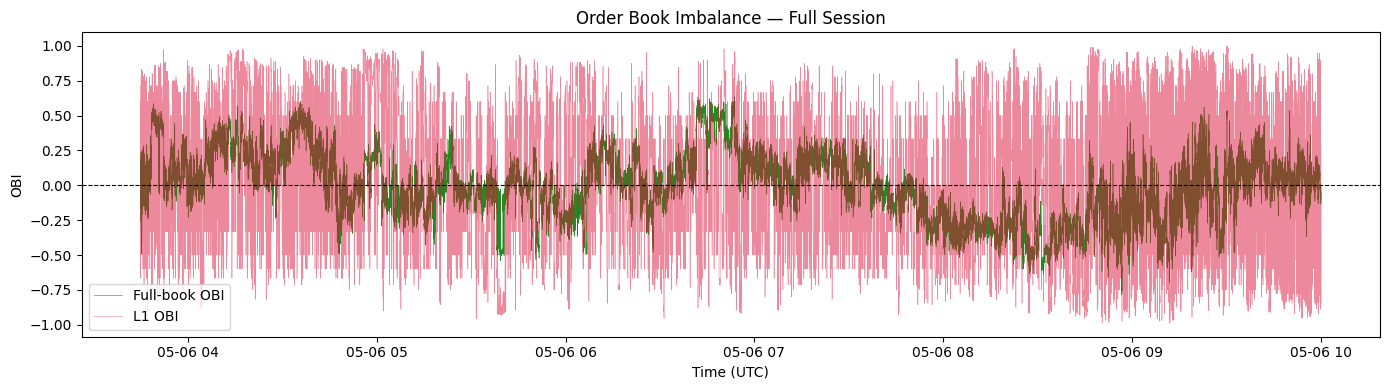

In [11]:
# OBI time series
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["ts"], df["obi"], linewidth=0.4, color="forestgreen", label="Full-book OBI")
ax.plot(df["ts"], df["l1_obi"], linewidth=0.4, color="crimson", alpha=0.5, label="L1 OBI")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("OBI")
ax.set_title("Order Book Imbalance — Full Session")
ax.legend()
plt.tight_layout()
plt.show()

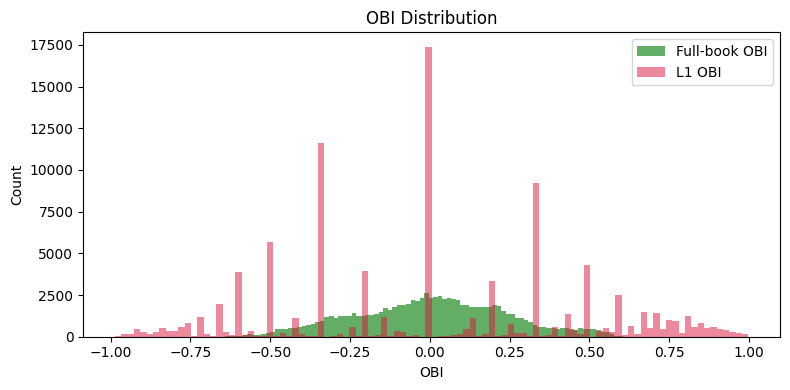

In [12]:
# OBI distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["obi"], bins=100, color="forestgreen", edgecolor="none", alpha=0.7, label="Full-book OBI")
ax.hist(df["l1_obi"], bins=100, color="crimson", edgecolor="none", alpha=0.5, label="L1 OBI")
ax.set_xlabel("OBI")
ax.set_ylabel("Count")
ax.set_title("OBI Distribution")
ax.legend()
plt.tight_layout()
plt.show()

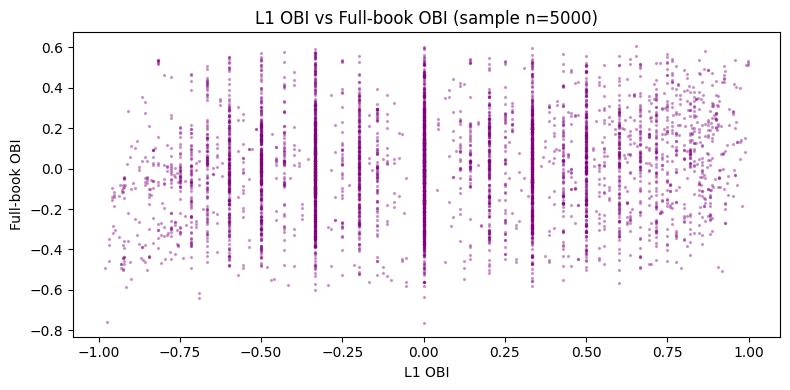

In [13]:
# L1 OBI vs Full-book OBI scatter (sample 5000 pts for clarity)
sample = df[["l1_obi", "obi"]].sample(min(5000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(sample["l1_obi"], sample["obi"], s=2, alpha=0.3, color="purple")
ax.set_xlabel("L1 OBI")
ax.set_ylabel("Full-book OBI")
ax.set_title("L1 OBI vs Full-book OBI (sample n=5000)")
plt.tight_layout()
plt.show()

## Section 5 — Depth Profile

Mean quantity and order count at each of the 20 price levels across the session.

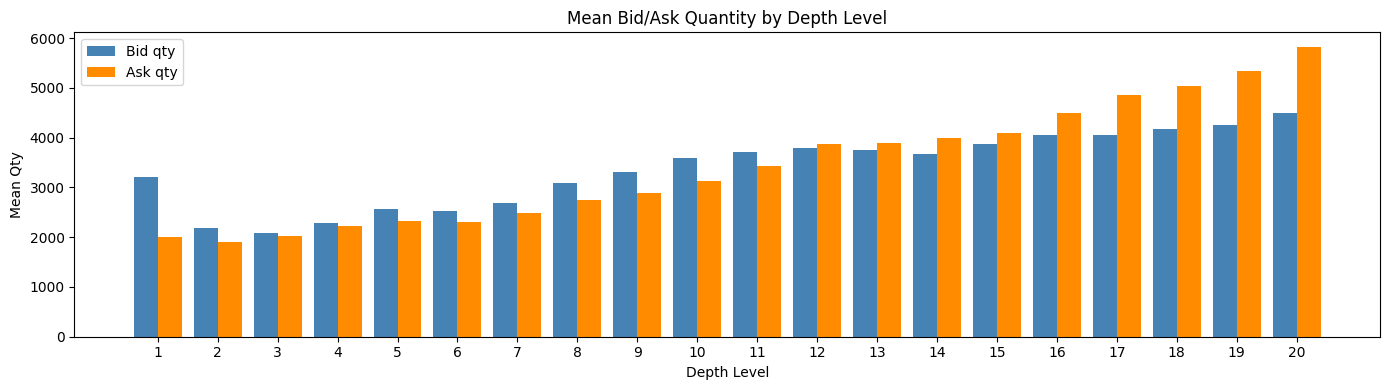

In [14]:
level_nums = list(range(1, 21))
mean_bid_qty    = [df[f"bid_qty_{l:02d}"].mean()    for l in level_nums]
mean_ask_qty    = [df[f"ask_qty_{l:02d}"].mean()    for l in level_nums]
mean_bid_orders = [df[f"bid_orders_{l:02d}"].mean() for l in level_nums]
mean_ask_orders = [df[f"ask_orders_{l:02d}"].mean() for l in level_nums]

x = np.arange(len(level_nums))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(x - width/2, mean_bid_qty, width, label="Bid qty", color="steelblue")
ax.bar(x + width/2, mean_ask_qty, width, label="Ask qty", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(level_nums)
ax.set_xlabel("Depth Level")
ax.set_ylabel("Mean Qty")
ax.set_title("Mean Bid/Ask Quantity by Depth Level")
ax.legend()
plt.tight_layout()
plt.show()

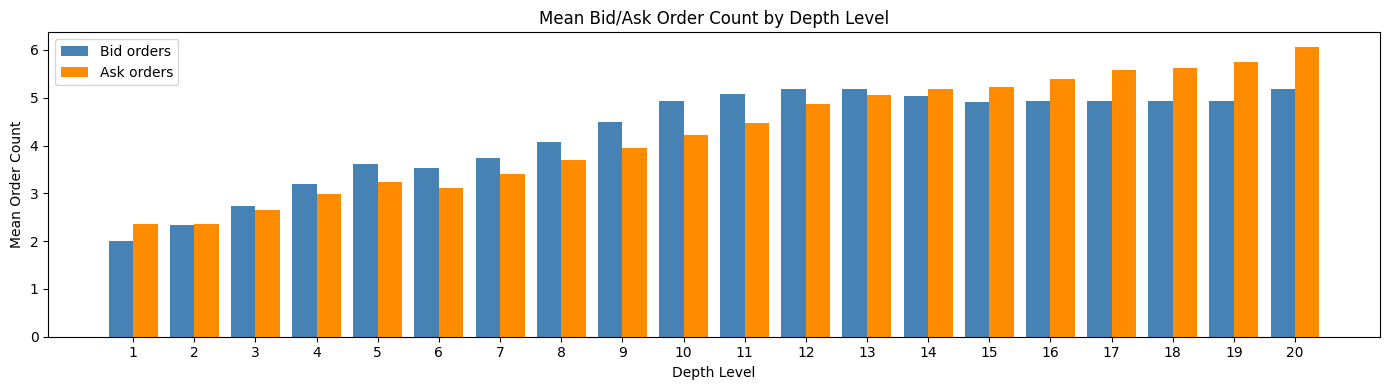

In [15]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(x - width/2, mean_bid_orders, width, label="Bid orders", color="steelblue")
ax.bar(x + width/2, mean_ask_orders, width, label="Ask orders", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(level_nums)
ax.set_xlabel("Depth Level")
ax.set_ylabel("Mean Order Count")
ax.set_title("Mean Bid/Ask Order Count by Depth Level")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Levels that are typically zero (mean qty < 1)
inactive_bid = [l for l, q in zip(level_nums, mean_bid_qty) if q < 1]
inactive_ask = [l for l, q in zip(level_nums, mean_ask_qty) if q < 1]
print(f"Typically inactive bid levels (mean qty < 1): {inactive_bid}")
print(f"Typically inactive ask levels (mean qty < 1): {inactive_ask}")

Typically inactive bid levels (mean qty < 1): []
Typically inactive ask levels (mean qty < 1): []


## Section 6 — Order Fragmentation

Average order size = qty / orders at each level.  
Fragmentation index = std(avg_sizes) / mean(avg_sizes) across top-5 levels — higher means more uneven order distribution.

In [17]:
TOP = 5
top_levels = [f"{i:02d}" for i in range(1, TOP + 1)]

# Average order size per level (bid side)
for l in top_levels:
    orders_col = f"bid_orders_{l}"
    qty_col    = f"bid_qty_{l}"
    df[f"bid_avg_size_{l}"] = df[qty_col] / df[orders_col].clip(lower=1)

bid_avg_size_cols = [f"bid_avg_size_{l}" for l in top_levels]

# Fragmentation index across top-5 bid levels per row
sizes_matrix = df[bid_avg_size_cols].values
frag_std  = np.std(sizes_matrix, axis=1)
frag_mean = np.mean(sizes_matrix, axis=1)
df["frag_index"] = frag_std / (frag_mean + 1e-9)

print("Fragmentation index (top-5 bid levels) summary:")
print(df["frag_index"].describe())

Fragmentation index (top-5 bid levels) summary:
count    94476.000000
mean         0.369889
std          0.390819
min          0.000000
25%          0.089874
50%          0.282038
75%          0.523025
max          1.800000
Name: frag_index, dtype: float64


In [18]:
# Print mean avg order size per level for bid and ask
print("Mean avg bid order size per level (top 5):")
for l in top_levels:
    print(f"  Level {l}: {df[f'bid_avg_size_{l}'].mean():.2f} lots/order")

print("\nMean avg ask order size per level (top 5):")
for l in top_levels:
    ask_avg = df[f"ask_qty_{l}"] / df[f"ask_orders_{l}"].clip(lower=1)
    print(f"  Level {l}: {ask_avg.mean():.2f} lots/order")

Mean avg bid order size per level (top 5):
  Level 01: 1426.69 lots/order
  Level 02: 909.79 lots/order
  Level 03: 743.09 lots/order
  Level 04: 690.58 lots/order
  Level 05: 677.62 lots/order

Mean avg ask order size per level (top 5):
  Level 01: 875.47 lots/order
  Level 02: 794.27 lots/order
  Level 03: 718.77 lots/order
  Level 04: 680.27 lots/order
  Level 05: 670.04 lots/order


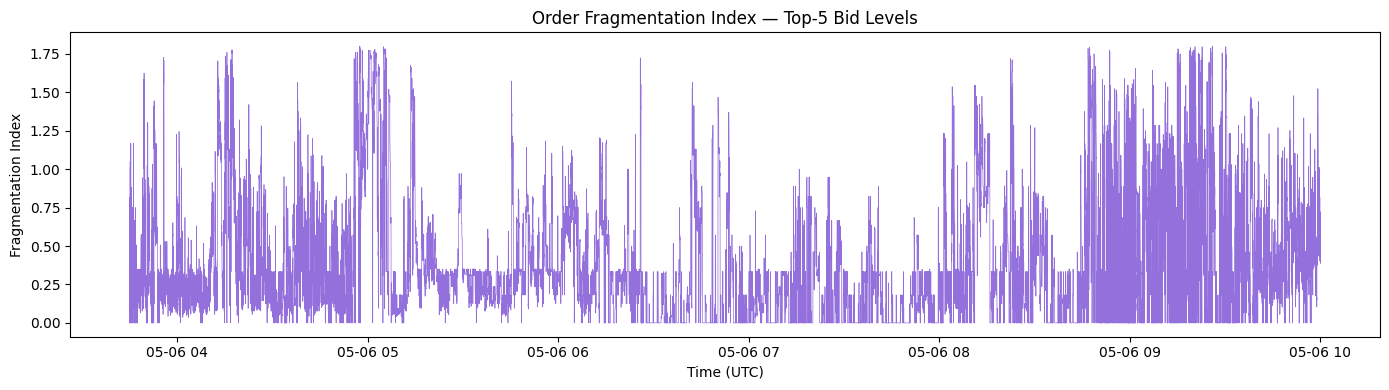

In [19]:
# Fragmentation index time series
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["ts"], df["frag_index"], linewidth=0.5, color="mediumpurple")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Fragmentation Index")
ax.set_title("Order Fragmentation Index — Top-5 Bid Levels")
plt.tight_layout()
plt.show()

## Section 7 — Data Quality

In [20]:
# NaN counts per column (only show columns with NaNs)
nan_counts = df.isnull().sum()
nan_nonzero = nan_counts[nan_counts > 0]
if nan_nonzero.empty:
    print("No NaN values found in any column.")
else:
    print("Columns with NaN values:")
    print(nan_nonzero.to_string())

No NaN values found in any column.


In [21]:
# Bad ticks — zero bid or ask price at L1
bad_bid = (df["bid_price_01"] == 0).sum()
bad_ask = (df["ask_price_01"] == 0).sum()
print(f"Rows with bid_price_01 == 0 (bad tick): {bad_bid:,} ({bad_bid/len(df)*100:.2f}%)")
print(f"Rows with ask_price_01 == 0 (bad tick): {bad_ask:,} ({bad_ask/len(df)*100:.2f}%)")

Rows with bid_price_01 == 0 (bad tick): 0 (0.00%)
Rows with ask_price_01 == 0 (bad tick): 0 (0.00%)


In [22]:
# Response code value counts
print("bid_response_code value counts:")
print(df["bid_response_code"].value_counts().to_string())
print("\nask_response_code value counts:")
print(df["ask_response_code"].value_counts().to_string())

bid_response_code value counts:
bid_response_code
41    94476

ask_response_code value counts:
ask_response_code
51    94476


In [23]:
# Crossed book: spread < 0
crossed = (df["spread"] < 0).sum()
print(f"Rows with crossed book (spread < 0): {crossed:,} ({crossed/len(df)*100:.3f}%)")

Rows with crossed book (spread < 0): 1 (0.001%)


In [24]:
# Clean summary
print("=" * 50)
print("DATA QUALITY SUMMARY")
print("=" * 50)
print(f"Total rows               : {len(df):,}")
print(f"Columns with NaN values  : {len(nan_nonzero)}")
print(f"Bad ticks (bid L1 == 0)  : {bad_bid:,} ({bad_bid/len(df)*100:.2f}%)")
print(f"Bad ticks (ask L1 == 0)  : {bad_ask:,} ({bad_ask/len(df)*100:.2f}%)")
print(f"Crossed book rows        : {crossed:,} ({crossed/len(df)*100:.3f}%)")
print(f"Unique bid_response_codes: {df['bid_response_code'].nunique()}")
print(f"Unique ask_response_codes: {df['ask_response_code'].nunique()}")
print("=" * 50)

DATA QUALITY SUMMARY
Total rows               : 94,476
Columns with NaN values  : 0
Bad ticks (bid L1 == 0)  : 0 (0.00%)
Bad ticks (ask L1 == 0)  : 0 (0.00%)
Crossed book rows        : 1 (0.001%)
Unique bid_response_codes: 1
Unique ask_response_codes: 1
